# News Analysis — ข่าวเลือกตั้ง 2569
วิเคราะห์ข่าวเลือกตั้งจากสำนักข่าวไทย ปี 2569:
1. **Scrape** ข่าวจาก RSS / Google News
2. **นับจำนวนข่าว** แยกสำนักข่าว × พรรค
3. **Sentiment / Tone** ของแต่ละข่าว
4. **Correlate** กับผลคะแนนเลือกตั้งในเขตลำปาง

---
## 0. Setup

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

CLEAN  = Path('cleaned/')
OUT    = Path('news_data/')
OUT.mkdir(exist_ok=True)

# โหลด election data
results = pd.read_csv(CLEAN / 'master_results_cleaned.csv')
summary = pd.read_csv(CLEAN / 'master_summary_cleaned.csv')

# พรรคหลักที่ต้องการติดตาม (บช)
TOP_PARTIES = (
    results[(results['type']=='บช') & (results['unit_number'] != -1)]
    .groupby('name')['score'].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print('พรรคหลักที่จะติดตาม:')
for p in TOP_PARTIES:
    print(' -', p)

พรรคหลักที่จะติดตาม:
 - ประชาชน
 - เพื่อไทย
 - กล้าธรรม
 - ประชาธิปัตย์
 - ภูมิใจไทย
 - รวมไทยสร้างชาติ
 - คลองไทย
 - เศรษฐกิจ
 - เพื่อชาติไทย
 - ประชากรไทย


---
## 1. Scrape ข่าวจาก RSS Feeds

In [2]:
# RSS feeds สำนักข่าวไทยหลัก
RSS_SOURCES = {
    'ไทยรัฐ':       'https://www.thairath.co.th/rss/news.xml',
    'มติชน':        'https://www.matichon.co.th/feed',
    'ไทยโพสต์':     'https://www.thaipost.net/feed',
    'ประชาชาติ':    'https://www.prachachat.net/feed',
    'The Standard': 'https://thestandard.co/feed/',
    'Workpoint':    'https://workpointtoday.com/feed/',
    'Beartai':      'https://www.beartai.com/feed',
    'The Matter':   'https://thematter.co/feed',
}

HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; NewsBot/1.0)'}

def parse_rss(source_name, url, timeout=10):
    """ดึง RSS และ parse เป็น list of dict"""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=timeout)
        resp.encoding = 'utf-8'
        soup = BeautifulSoup(resp.content, 'xml')
        items = []
        for item in soup.find_all('item'):
            title   = item.find('title')
            desc    = item.find('description')
            pubdate = item.find('pubDate')
            link    = item.find('link')
            items.append({
                'source':  source_name,
                'title':   title.get_text(strip=True)   if title   else '',
                'desc':    BeautifulSoup(desc.get_text(), 'html.parser').get_text(strip=True)[:500] if desc else '',
                'pubdate': pubdate.get_text(strip=True) if pubdate else '',
                'url':     link.get_text(strip=True)    if link    else '',
            })
        return items
    except Exception as e:
        print(f'  [{source_name}] ERROR: {e}')
        return []

all_news = []
for name, url in RSS_SOURCES.items():
    items = parse_rss(name, url)
    print(f'  {name:15s}: {len(items):3d} items')
    all_news.extend(items)
    time.sleep(0.5)

news_df = pd.DataFrame(all_news)
print(f'\nรวม: {len(news_df)} ข่าว')
news_df.head(3)

  ไทยรัฐ         :   0 items


  มติชน          :  50 items


  ไทยโพสต์       :  10 items


  ประชาชาติ      :  30 items


  The Standard   :  20 items


  Workpoint      :  20 items


  Beartai        :  20 items


  The Matter     :  10 items



รวม: 160 ข่าว


,source,title,desc,pubdate,url
0,มติชน,"โชว์ยอดจองทั่วปท. โตโยต้า28,580คัน สูงสุดช่วงง...","โชว์ยอดจองทั่วปท. โตโยต้า28,580คัน สูงสุดเป็นป...","Wed, 08 Apr 2026 05:23:33 +0000",https://www.matichon.co.th/economy/auto/news_5...
1,มติชน,ปิดฉากความสำเร็จ! Workshop “บุกตลาดจีน” รุ่น 2...,ปิดฉากความสำเร็จ สำหรับกิจกรรม “T-Brand to Chi...,"Wed, 08 Apr 2026 05:22:28 +0000",https://www.matichon.co.th/economy/news_5669300
2,มติชน,สำนักงานทรัพย์สินทางปัญญาอาเซียน ผนึกรับมือควา...,สำนักงานทรัพย์สินทางปัญญาอาเซียน ผนึกรับมือควา...,"Wed, 08 Apr 2026 05:19:33 +0000",https://www.matichon.co.th/economy/news_5669329


## 2. Filter ข่าวที่เกี่ยวกับการเลือกตั้ง

In [3]:
# keyword สำหรับกรองข่าวเลือกตั้ง
ELECTION_KW = [
    'เลือกตั้ง', 'ผู้สมัคร', 'สส', 'ส.ส.', 'พรรค', 'หาเสียง',
    'กกต', 'บัตร', 'คะแนน', 'โหวต', 'นโยบาย', 'รัฐบาล',
]

def has_election_kw(text):
    return any(kw in str(text) for kw in ELECTION_KW)

election_news = news_df[
    news_df['title'].apply(has_election_kw) |
    news_df['desc'].apply(has_election_kw)
].copy()

print(f'ข่าวเลือกตั้ง: {len(election_news)} จาก {len(news_df)} ทั้งหมด')
election_news[['source','title']].head(10)

ข่าวเลือกตั้ง: 22 จาก 160 ทั้งหมด


,source,title
8,มติชน,สุริยะ-2 รมช. เข้า ก.เกษตรวันแรก ชู 5 นโยบายลุ...
9,มติชน,พรรคร่วมฝ่ายค้าน ชูจุดยืน ผลักดัน พ.ร.บ.อากาศส...
16,มติชน,พีมูฟ ยื่นหนังสือ ขอพบ อนุทิน 27 เม.ย.นี้ ชง 7...
17,มติชน,ศาลรธน. ไฟเขียว กกต.ขยายเวลา 15 วัน ส่งคำชี้แจ...
21,มติชน,‘กล้าธรรม’ วาง 20 ขุนพล ชำแหละนโยบายรบ.ทุกมิติ...
24,มติชน,อัสสัมชัญ ศรีราชา ทวงบัลลังก์แชมป์ภาคตะวันออก ...
28,มติชน,นิกร รายงานตัวส.ส.ปาร์ตี้ลิสต์ ก่อนสภามีมติ ตั...
37,มติชน,สุรทิน โต้ หมอวรงค์ สวัสดิการส.ส.ไม่ใช่บำนาญ ช...
50,ไทยโพสต์,‘พีมูฟ’ นัดพบ ‘อนุทิน’ 27 เม.ย.
55,ไทยโพสต์,‘น้ำมันพืชกุ๊ก’ รับมอบประกาศนียบัตรเครื่องหมาย...


## 3. Tag พรรคที่ถูกพูดถึงในแต่ละข่าว

In [4]:
# Alias สำหรับค้นหาชื่อพรรคในข่าว
PARTY_ALIAS = {
    'เพื่อไทย':          ['เพื่อไทย', 'พท.', 'pheu thai'],
    'ประชาชน':           ['ประชาชน', 'ppp', 'people\'s party'],
    'กล้าธรรม':          ['กล้าธรรม'],
    'ประชาธิปัตย์':      ['ประชาธิปัตย์', 'ปชป', 'democrat'],
    'ภูมิใจไทย':         ['ภูมิใจไทย', 'ภท.', 'bhumjaithai'],
    'รวมไทยสร้างชาติ':   ['รวมไทยสร้างชาติ', 'รทสช', 'utc'],
    'คลองไทย':           ['คลองไทย'],
    'เศรษฐกิจ':          ['เศรษฐกิจใหม่', 'เศรษฐกิจ'],
    'เพื่อชาติไทย':      ['เพื่อชาติ'],
    'ประชากรไทย':        ['ประชากรไทย'],
}

def tag_parties(row):
    text = str(row['title']) + ' ' + str(row['desc'])
    found = []
    for party, aliases in PARTY_ALIAS.items():
        if any(a.lower() in text.lower() for a in aliases):
            found.append(party)
    return found

election_news['parties_mentioned'] = election_news.apply(tag_parties, axis=1)
election_news['party_count'] = election_news['parties_mentioned'].apply(len)

# explode เพื่อนับต่อพรรค
news_party = election_news[election_news['party_count'] > 0].copy()
news_exploded = news_party.explode('parties_mentioned').rename(columns={'parties_mentioned': 'party'})

print(f'ข่าวที่ระบุพรรคได้: {len(news_party)} ข่าว')
print(f'rows หลัง explode: {len(news_exploded)}')

ข่าวที่ระบุพรรคได้: 5 ข่าว
rows หลัง explode: 5


# % เชิงบวก / ลบ ต่อพรรค
if len(news_exploded) == 0:
    print('ยังไม่มีข้อมูลข่าวที่ tag พรรคได้ — ข้ามขั้นตอนนี้')
else:
    party_sent = (
        news_exploded.groupby(['party','sentiment'])
        .size()
        .unstack(fill_value=0)
    )
    party_sent['total'] = party_sent.sum(axis=1)
    for col in ['positive','neutral','negative']:
        if col in party_sent.columns:
            party_sent[f'{col}_pct'] = party_sent[col] / party_sent['total'] * 100

    print('Sentiment % ต่อพรรค:')
    display_cols = [c for c in ['positive_pct','neutral_pct','negative_pct','total'] if c in party_sent.columns]
    sort_by = 'positive_pct' if 'positive_pct' in display_cols else 'total'
    print(party_sent[display_cols].sort_values(sort_by, ascending=False))

จำนวนข่าวแยกสำนักข่าว × พรรค:
party         กล้าธรรม  ประชาชน  เศรษฐกิจ
source                                   
Beartai              0        1         0
The Standard         0        2         0
ประชาชาติ            0        0         1
มติชน                1        0         0


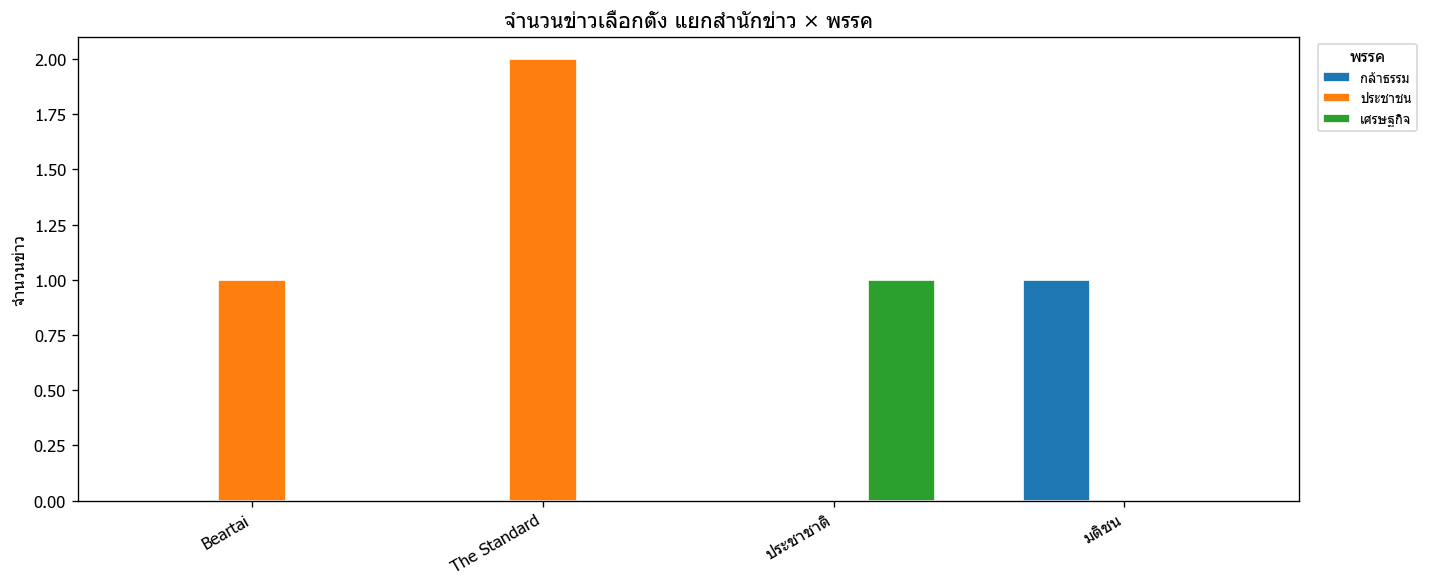

In [5]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Tahoma'
plt.rcParams['figure.dpi'] = 120

# pivot: สำนักข่าว × พรรค
pivot_count = (
    news_exploded.groupby(['source','party'])
    .size()
    .unstack(fill_value=0)
)

print('จำนวนข่าวแยกสำนักข่าว × พรรค:')
print(pivot_count)

if len(pivot_count) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    pivot_count.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')
    ax.set_title('จำนวนข่าวเลือกตั้ง แยกสำนักข่าว × พรรค', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('จำนวนข่าว')
    ax.legend(title='พรรค', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('ไม่พบข่าวที่ tag พรรคได้ — อาจต้องรอข่าวหรือปรับ keyword')

## 5. Sentiment Analysis (Rule-based Thai)

Sentiment แยกสำนักข่าว:
sentiment     neutral
source               
Beartai             1
The Standard        2
ประชาชาติ           1
มติชน               1


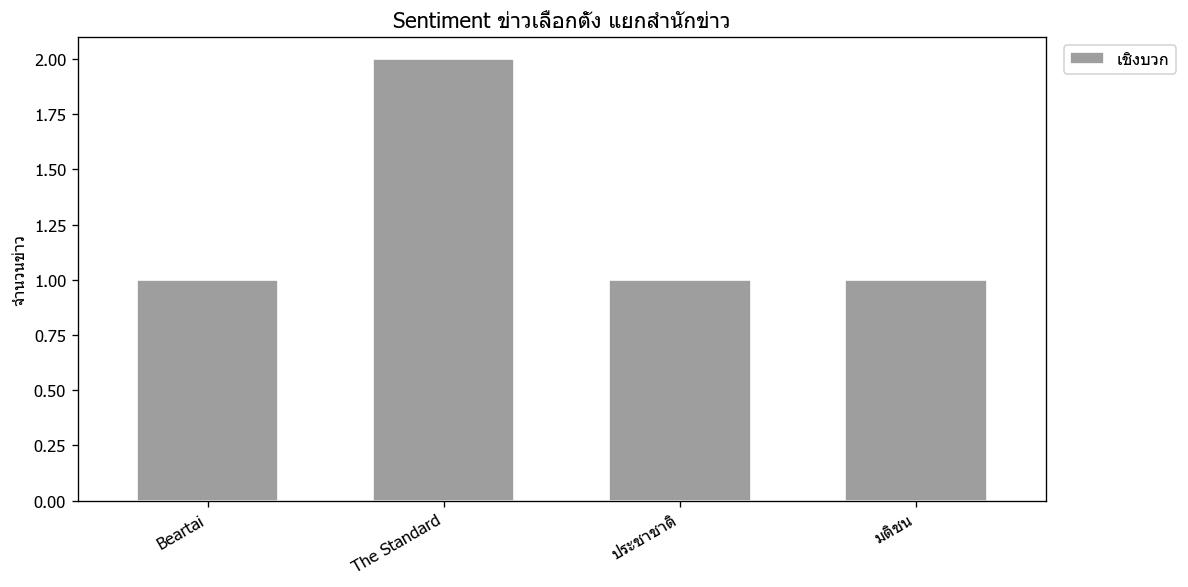

In [6]:
# Rule-based sentiment สำหรับภาษาไทย
POS_WORDS = [
    'ชนะ','ได้รับ','ยอดเยี่ยม','ดีเด่น','สำเร็จ','ได้คะแนน','นำ','ครอง',
    'สนับสนุน','นิยม','ชื่นชม','เชื่อมั่น','โดดเด่น','ก้าวหน้า','ประสบความสำเร็จ',
    'ยอมรับ','ผ่าน','เข้มแข็ง','มั่นคง','ดีงาม',
]
NEG_WORDS = [
    'แพ้','ล้มเหลว','ทุจริต','ผิดกฎหมาย','ถูกร้อง','สอบสวน','วิจารณ์',
    'โจมตี','ปัญหา','อื้อฉาว','ถูกกล่าวหา','ยุบพรรค','ขัดแย้ง','ล้มเหลว',
    'ไม่ผ่าน','เสีย','ต่อต้าน','ประท้วง','ร้องเรียน','คดี',
]

def score_sentiment(text):
    t = str(text)
    pos = sum(1 for w in POS_WORDS if w in t)
    neg = sum(1 for w in NEG_WORDS if w in t)
    if pos > neg:   return 'positive'
    elif neg > pos: return 'negative'
    else:           return 'neutral'

news_exploded['text_combined'] = news_exploded['title'] + ' ' + news_exploded['desc']
news_exploded['sentiment'] = news_exploded['text_combined'].apply(score_sentiment)

sent_pivot = (
    news_exploded.groupby(['source','sentiment'])
    .size()
    .unstack(fill_value=0)
)

print('Sentiment แยกสำนักข่าว:')
print(sent_pivot)

if len(sent_pivot) > 0:
    colors = {'positive': '#4CAF50', 'neutral': '#9E9E9E', 'negative': '#F44336'}
    cols = [c for c in ['positive','neutral','negative'] if c in sent_pivot.columns]
    fig, ax = plt.subplots(figsize=(10, 5))
    sent_pivot[cols].plot(kind='bar', ax=ax, color=[colors[c] for c in cols],
                          stacked=True, width=0.6, edgecolor='white')
    ax.set_title('Sentiment ข่าวเลือกตั้ง แยกสำนักข่าว', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('จำนวนข่าว')
    ax.legend(['เชิงบวก','กลาง','เชิงลบ'], bbox_to_anchor=(1.01,1), loc='upper left')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 6. Sentiment ต่อพรรค แยกสำนักข่าว

In [7]:
# % เชิงบวก / ลบ ต่อพรรค
if len(news_exploded) == 0:
    print('ยังไม่มีข้อมูลข่าวที่ tag พรรคได้ — ข้ามขั้นตอนนี้')
else:
    party_sent = (
        news_exploded.groupby(["party","sentiment"])
        .size()
        .unstack(fill_value=0)
    )
    party_sent["total"] = party_sent.sum(axis=1)
    for col in ["positive","neutral","negative"]:
        if col in party_sent.columns:
            party_sent[f"{col}_pct"] = party_sent[col] / party_sent["total"] * 100

    print("Sentiment % ต่อพรรค:")
    display_cols = [c for c in ["positive_pct","neutral_pct","negative_pct","total"] if c in party_sent.columns]
    sort_by = "positive_pct" if "positive_pct" in display_cols else "total"
    print(party_sent[display_cols].sort_values(sort_by, ascending=False))


Sentiment % ต่อพรรค:
sentiment  neutral_pct  total
party                        
ประชาชน          100.0      3
กล้าธรรม         100.0      1
เศรษฐกิจ         100.0      1


## 7. Correlate: จำนวนข่าว vs คะแนนเลือกตั้ง

In [8]:
# คะแนนรวมพรรค บช ในเขต
party_score = (
    results[(results['type']=='บช') & (results['unit_number'] != -1)]
    .groupby('name')['score'].sum()
    .reset_index()
    .rename(columns={'name':'party','score':'election_score'})
)

# จำนวนข่าวต่อพรรค (รวมทุกสำนัก)
news_count = (
    news_exploded.groupby('party')
    .size()
    .reset_index(name='news_count')
)

# จำนวนข่าวเชิงบวกต่อพรรค
pos_count = (
    news_exploded[news_exploded['sentiment']=='positive']
    .groupby('party').size()
    .reset_index(name='pos_news_count')
)

corr_df = party_score.merge(news_count, on='party', how='left')
corr_df = corr_df.merge(pos_count, on='party', how='left')
corr_df = corr_df.fillna(0)
corr_df = corr_df.sort_values('election_score', ascending=False)

print('ตารางสรุป: คะแนนเลือกตั้ง vs จำนวนข่าว')
print(corr_df.to_string(index=False))

ตารางสรุป: คะแนนเลือกตั้ง vs จำนวนข่าว
                      party  election_score  news_count  pos_news_count
                    ประชาชน           23949         3.0             0.0
                   เพื่อไทย           20730         0.0             0.0
                   กล้าธรรม           15816         1.0             0.0
               ประชาธิปัตย์           15796         0.0             0.0
                  ภูมิใจไทย            6040         0.0             0.0
            รวมไทยสร้างชาติ            5556         0.0             0.0
                    คลองไทย            4214         0.0             0.0
                   เศรษฐกิจ            3713         1.0             0.0
               เพื่อชาติไทย            3498         0.0             0.0
                 ประชากรไทย            3344         0.0             0.0
             รวมพลังประชาชน            3023         0.0             0.0
             พลังไทยรักชาติ            2774         0.0             0.0
                   ประชาไ

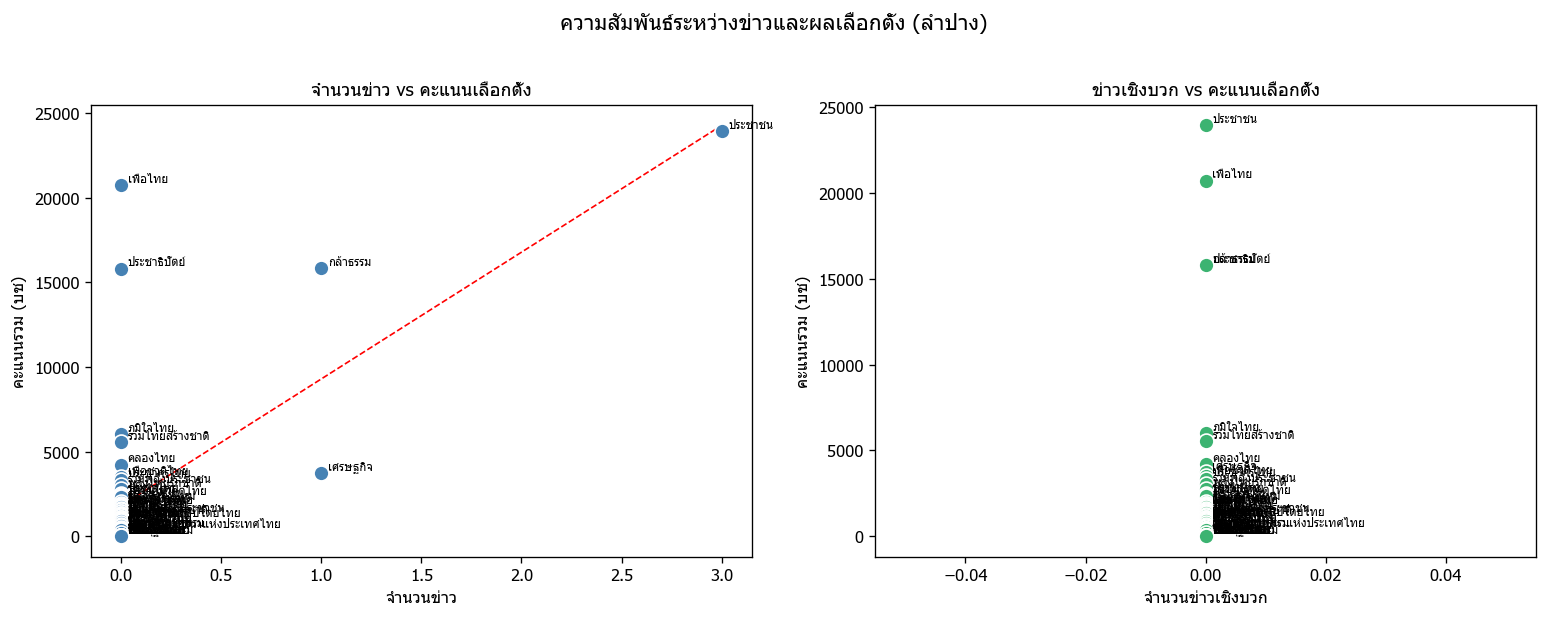

In [9]:
if corr_df['news_count'].sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: news_count vs election_score
    ax = axes[0]
    ax.scatter(corr_df['news_count'], corr_df['election_score'],
               s=80, color='steelblue', edgecolors='white', zorder=3)
    for _, row in corr_df.iterrows():
        ax.annotate(row['party'], (row['news_count'], row['election_score']),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')
    if len(corr_df) > 2:
        z = np.polyfit(corr_df['news_count'], corr_df['election_score'], 1)
        xr = np.linspace(corr_df['news_count'].min(), corr_df['news_count'].max(), 50)
        ax.plot(xr, np.poly1d(z)(xr), 'r--', linewidth=1)
    ax.set_title('จำนวนข่าว vs คะแนนเลือกตั้ง', fontsize=11)
    ax.set_xlabel('จำนวนข่าว')
    ax.set_ylabel('คะแนนรวม (บช)')

    # Scatter: pos_news vs election_score
    ax = axes[1]
    ax.scatter(corr_df['pos_news_count'], corr_df['election_score'],
               s=80, color='mediumseagreen', edgecolors='white', zorder=3)
    for _, row in corr_df.iterrows():
        ax.annotate(row['party'], (row['pos_news_count'], row['election_score']),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')
    ax.set_title('ข่าวเชิงบวก vs คะแนนเลือกตั้ง', fontsize=11)
    ax.set_xlabel('จำนวนข่าวเชิงบวก')
    ax.set_ylabel('คะแนนรวม (บช)')

    plt.suptitle('ความสัมพันธ์ระหว่างข่าวและผลเลือกตั้ง (ลำปาง)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('ยังไม่มีข้อมูลข่าวเพียงพอสำหรับ correlation')

## 8. Export ข้อมูลข่าว

In [10]:
# save ทุก raw news
news_df.to_csv(OUT / 'news_raw.csv', index=False, encoding='utf-8-sig')

# save election news + sentiment
if len(news_exploded) > 0:
    news_exploded.drop(columns=['text_combined'], errors='ignore')\
                 .to_csv(OUT / 'news_election_tagged.csv', index=False, encoding='utf-8-sig')

# save correlation table
corr_df.to_csv(OUT / 'news_vs_score.csv', index=False, encoding='utf-8-sig')

print('Saved:')
for f in sorted(OUT.glob('*.csv')):
    print(f'  news_data/{f.name}')

Saved:
  news_data/news_election_tagged.csv
  news_data/news_raw.csv
  news_data/news_vs_score.csv
